# 08 – Raportin kuvat ja taulukot (englanniksi)

**Tehtävä:** raporttia ja blogia varten tehdään englanninkieliset kuvat ja taulukkoyhteenveto. Muistio ei aja malleja vaan lukee tulokset kansiosta `results/` (muistiot 05 ja 06).

**Tulokset:**
- `reports/figures/res_*.png`: kuvat
- `results/summary_tables.md`: keskeiset luvut englanniksi (raportin taulukoiden pohja)

Kuvissa käytetään puolueiden englanninkielisiä lyhytnimiä (`config.PARTY_SHORT_EN`): Left, SDP, Greens, Centre, SPP, CD, NCP, Finns. Tulkinnat ovat muistiossa `07_tulokset`, ja termien suomenkieliset vastineet ovat muistion 05 käsitetaulukossa.

In [1]:
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
import config

TULOKSET = "../results/"
KUVAT = "../reports/figures/"
KAUDET = ["2015-2019", "2019-2023", "2023-2027"]
PUOLUEET = config.MAIN_PARTIES
VARIT = config.PARTY_COLORS
EN = config.PARTY_SHORT_EN           # englanninkieliset nimet kuviin
EN_LISTA = [EN[p] for p in PUOLUEET]

yhteenveto = pd.read_csv(TULOKSET + "party_summary.csv")
parit = pd.read_csv(TULOKSET + "party_pairwise.csv")
monimuotoisuus = pd.read_csv(TULOKSET + "party_diversity.csv")
profiilit = pd.read_csv(TULOKSET + "party_mp_profiles.csv")
hallitus = pd.read_csv(TULOKSET + "government_summary.csv")
ilman_ministereita = pd.read_csv(TULOKSET + "party_nominister_summary.csv")
ilman_tyylisanoja = pd.read_csv(TULOKSET + "party_nostyle_summary.csv")
leaveout = pd.read_csv(TULOKSET + "leaveout_party_pairs_term.csv")
leaveout_hallitus = pd.read_csv(TULOKSET + "leaveout_gov_term.csv")
leaveout_vuosi = pd.read_csv(TULOKSET + "leaveout_party_pairs_year.csv")
leaveout_hallitus_vuosi = pd.read_csv(TULOKSET + "leaveout_gov_year.csv")

taulukot = []   # summary_tables.md:n osat


def vali(arvot):
    """Keskiarvo sekä 10. ja 90. persentiili."""
    return pd.Series({"mean": arvot.mean(), "p10": arvot.quantile(0.1), "p90": arvot.quantile(0.9)})


def parimatriisi(taulu, arvosarake):
    """Symmetrinen puolueet × puolueet -taulukko pareittaisista arvoista (sarakkeet a ja b)."""
    m = taulu.groupby(["a", "b"])[arvosarake].mean().unstack().reindex(index=PUOLUEET, columns=PUOLUEET)
    return (m.fillna(0) + m.T.fillna(0)).rename_axis(index=None, columns=None)


def erottuvuusmatriisi(kausi):
    return parimatriisi(parit[(parit["term"] == kausi) & (parit["series"] == "real")], "d")


def polarisaatio_kausittain(taulu, sarja="real"):
    return taulu[taulu["series"] == sarja].groupby("term")["polarisation"].mean()


def samalla_puolella(kausi, a, b):
    hallitus = config.MAIN_GOVERNMENT[kausi]
    return (a in hallitus) == (b in hallitus)

## 1. Päätaulukot

In [2]:
rivit = []
for (kausi, sarja), osa in yhteenveto.groupby(["term", "series"]):
    rivit.append({
        "term": kausi, "labels": sarja,
        "balanced accuracy": osa["balanced_accuracy"].mean(),
        "macro-F1": osa["macro_f1"].mean(),
        "separability": osa["polarisation"].mean(),
        "separability p10": osa["polarisation"].quantile(0.1),
        "separability p90": osa["polarisation"].quantile(0.9),
    })
paataulukko = pd.DataFrame(rivit).round(3)
taulukot.append("## Party classifier, 8 parties, 300 training speeches per party\n\n"
                "`labels = random`: party labels shuffled across MPs (bias check).\n\n"
                + paataulukko.to_markdown(index=False))
paataulukko

,term,labels,balanced accuracy,macro-F1,separability,separability p10,separability p90
0,2015-2019,random,0.128,0.120,-0.007,-0.087,0.099
1,2015-2019,real,0.249,0.226,0.389,0.369,0.407
2,2019-2023,random,0.125,0.121,0.001,-0.049,0.065
3,2019-2023,real,0.278,0.255,0.451,0.402,0.485
4,2023-2027,random,0.121,0.114,-0.004,-0.014,0.009
5,2023-2027,real,0.330,0.281,0.559,0.528,0.595


In [3]:
kontrollit = pd.DataFrame({
    "parties": polarisaatio_kausittain(yhteenveto),
    "parties, no ministers": polarisaatio_kausittain(ilman_ministereita),
    "parties, no style words": polarisaatio_kausittain(ilman_tyylisanoja),
    "government vs opposition": polarisaatio_kausittain(hallitus),
    "government vs opposition, random": polarisaatio_kausittain(hallitus, "random"),
}).rename_axis("term").reset_index().round(3)
taulukot.append("## Separability: robustness and control task\n\n" + kontrollit.to_markdown(index=False))
kontrollit

,term,parties,"parties, no ministers","parties, no style words",government vs opposition,"government vs opposition, random"
0,2015-2019,0.389,0.389,0.386,0.360,0.002
1,2019-2023,0.451,0.464,0.451,0.467,0.005
2,2023-2027,0.559,0.548,0.547,0.520,-0.027


In [4]:
oikeat = parit[parit["series"] == "real"].copy()
oikeat["pair type"] = ["same side" if samalla_puolella(kausi, a, b) else "across government/opposition"
                       for kausi, a, b in zip(oikeat["term"], oikeat["a"], oikeat["b"])]
puolet = oikeat.groupby(["term", "pair type"])["d"].mean().unstack().round(3)
taulukot.append("## Separability of party pairs on the same side vs across the government–opposition line\n\n"
                "Main cabinet of each term; the Finns Party counted as government in 2015–19.\n\n" + puolet.to_markdown())
puolet

pair type,across government/opposition,same side
term,,
2015-2019,0.446,0.324
2019-2023,0.513,0.379
2023-2027,0.655,0.431


## 2. Kuva: polarisaatio (*polarisation*) kausittain

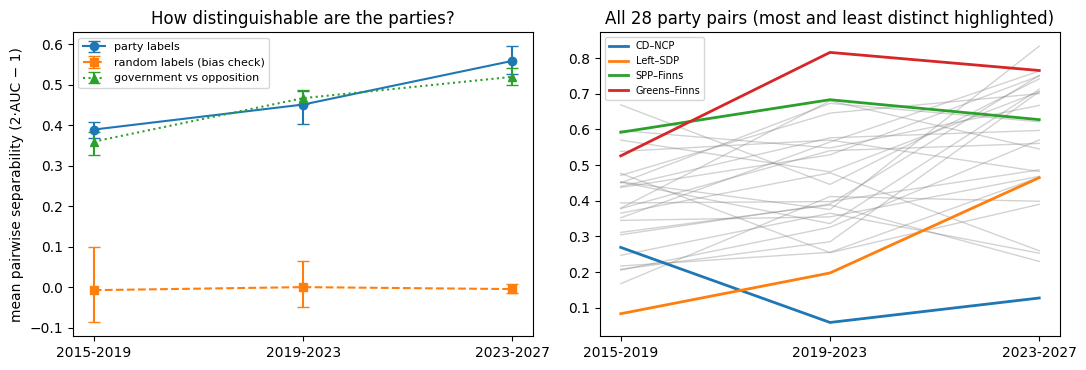

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(KAUDET))

sarjat = [
    (yhteenveto[yhteenveto["series"] == "real"], "party labels", "o-"),
    (yhteenveto[yhteenveto["series"] == "random"], "random labels (bias check)", "s--"),
    (hallitus[hallitus["series"] == "real"], "government vs opposition", "^:"),
]
for osa, nimi, tyyli in sarjat:
    luvut = osa.groupby("term")["polarisation"].apply(vali).unstack().reindex(KAUDET)
    ax[0].errorbar(x, luvut["mean"], yerr=[luvut["mean"] - luvut["p10"], luvut["p90"] - luvut["mean"]],
                   fmt=tyyli, capsize=4, label=nimi)
ax[0].set_xticks(x)
ax[0].set_xticklabels(KAUDET)
ax[0].set_ylabel("mean pairwise separability (2·AUC − 1)")
ax[0].set_title("How distinguishable are the parties?")
ax[0].legend(fontsize=8)

keskiarvot = oikeat.groupby(["term", "a", "b"])["d"].mean().reset_index()
keskiarvot["pair"] = keskiarvot["a"].map(EN) + "–" + keskiarvot["b"].map(EN)
leveä = keskiarvot.pivot(index="pair", columns="term", values="d")[KAUDET]
for pari, rivi in leveä.iterrows():
    ax[1].plot(x, rivi.values, color="grey", alpha=0.35, linewidth=1)
jarjestys = leveä.mean(axis=1).sort_values().index
for pari in [jarjestys[0], jarjestys[1], jarjestys[-2], jarjestys[-1]]:
    ax[1].plot(x, leveä.loc[pari].values, linewidth=2, label=pari)
ax[1].set_xticks(x)
ax[1].set_xticklabels(KAUDET)
ax[1].set_title("All 28 party pairs (most and least distinct highlighted)")
ax[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(KUVAT + "res_polarisation_by_term.png", bbox_inches="tight")
plt.show()

## 3. Kuva: erottuvuusmatriisit ja puoluekartat

Puoluekartta tehdään klassisella MDS:llä erottuvuusmatriisista. Akselien suunnat valitaan niin, että kartta on mahdollisimman samassa asennossa kuin edellisellä kaudella, mikä helpottaa vertailua.

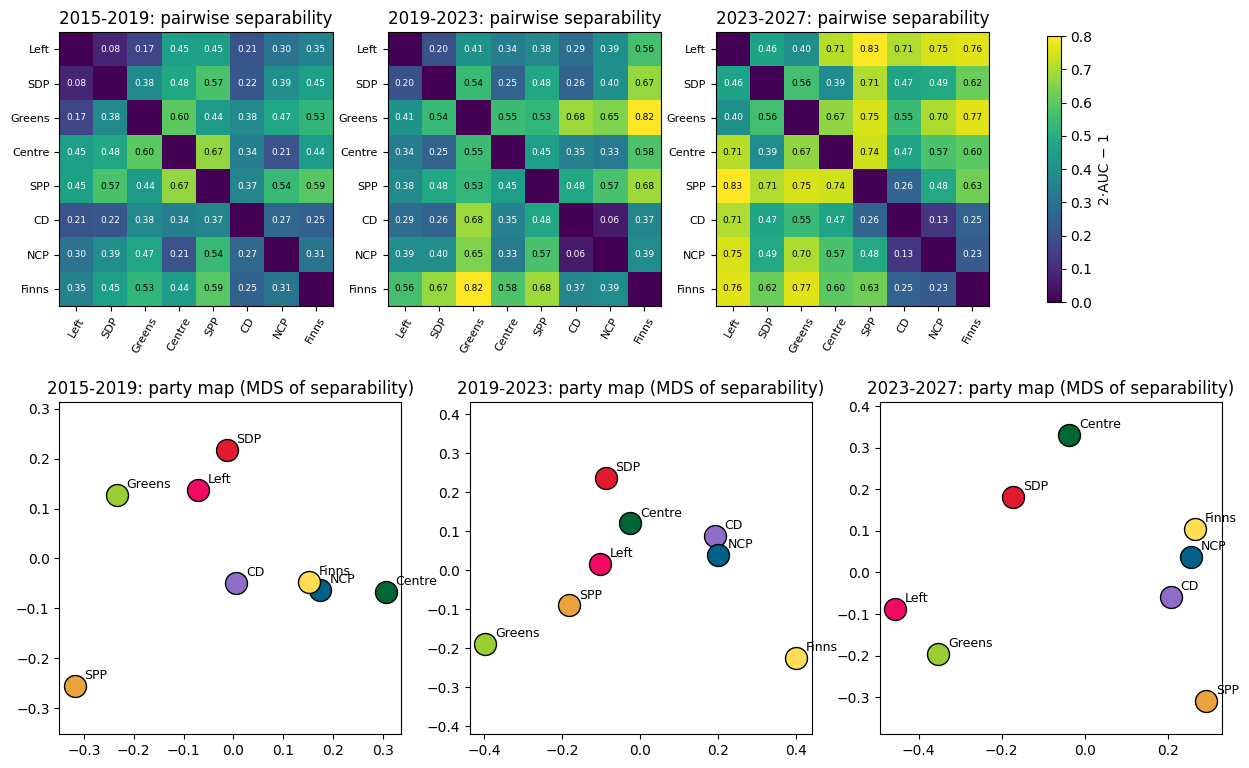

In [6]:
def klassinen_mds(etaisyydet):
    """Klassinen (Torgerson) MDS kahteen ulottuvuuteen."""
    D2 = np.asarray(etaisyydet) ** 2
    n = len(D2)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    ominaisarvot, ominaisvektorit = np.linalg.eigh(B)
    suurimmat = np.argsort(ominaisarvot)[::-1][:2]
    return ominaisvektorit[:, suurimmat] * np.sqrt(np.clip(ominaisarvot[suurimmat], 0, None))


fig, ax = plt.subplots(2, 3, figsize=(15, 9.5))
edellinen = None
for k, kausi in enumerate(KAUDET):
    matriisi = erottuvuusmatriisi(kausi)
    ax[0, k].imshow(matriisi.values, cmap="viridis", vmin=0, vmax=0.8)
    ax[0, k].set_xticks(range(len(PUOLUEET)))
    ax[0, k].set_xticklabels(EN_LISTA, rotation=60, fontsize=8)
    ax[0, k].set_yticks(range(len(PUOLUEET)))
    ax[0, k].set_yticklabels(EN_LISTA, fontsize=8)
    for i in range(len(PUOLUEET)):
        for j in range(len(PUOLUEET)):
            if i != j:
                arvo = matriisi.values[i, j]
                ax[0, k].text(j, i, f"{arvo:.2f}", ha="center", va="center", fontsize=6.5,
                              color="white" if arvo < 0.5 else "black")
    ax[0, k].set_title(f"{kausi}: pairwise separability")
    ax[0, k].grid(False)

    sijainnit = klassinen_mds(matriisi.values)
    if edellinen is not None:
        for akseli in range(2):
            if np.corrcoef(sijainnit[:, akseli], edellinen[:, akseli])[0, 1] < 0:
                sijainnit[:, akseli] = -sijainnit[:, akseli]
    edellinen = sijainnit
    for i, puolue in enumerate(PUOLUEET):
        ax[1, k].scatter(sijainnit[i, 0], sijainnit[i, 1], s=250, color=VARIT[puolue], edgecolor="black", zorder=3)
        ax[1, k].annotate(EN[puolue], sijainnit[i], xytext=(7, 5), textcoords="offset points", fontsize=9)
    ax[1, k].set_title(f"{kausi}: party map (MDS of separability)")
    ax[1, k].set_aspect("equal", adjustable="datalim")

fig.colorbar(ax[0, -1].images[0], ax=ax[0, :], shrink=0.8, label="2·AUC − 1")
plt.savefig(KUVAT + "res_party_maps.png", bbox_inches="tight")
plt.show()

## 4. Kuva: edustajat kartalla

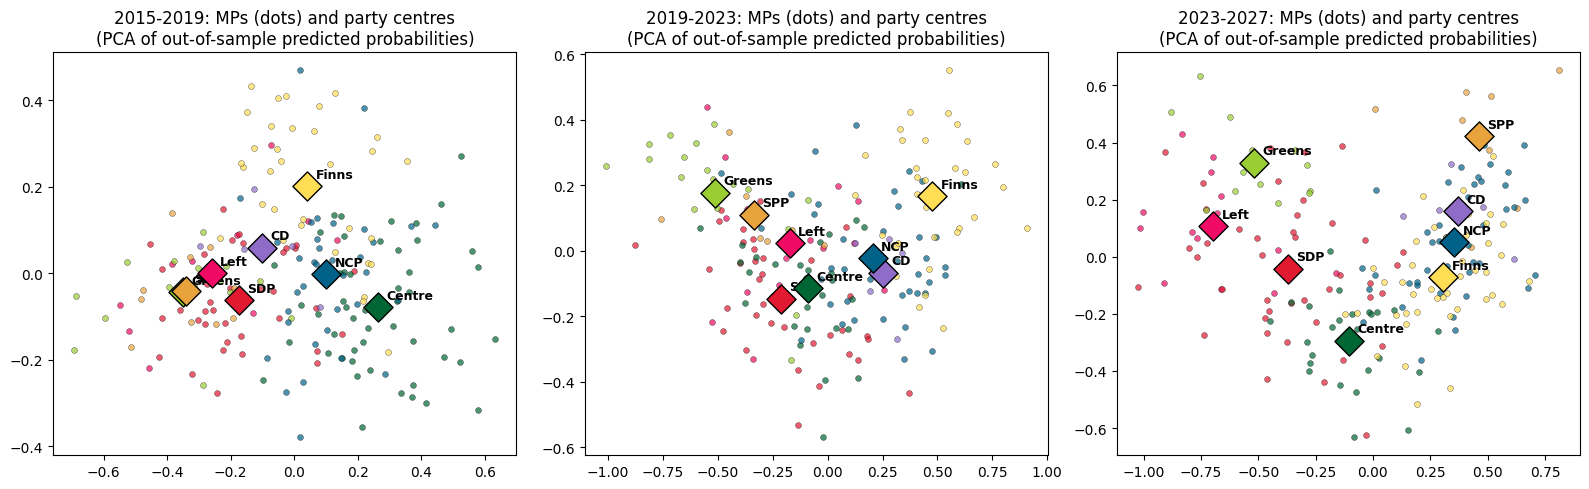

In [7]:
sarakkeet = ["p_" + p for p in PUOLUEET]
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for k, kausi in enumerate(KAUDET):
    osa = profiilit[profiilit["term"] == kausi]
    edustajat = osa.groupby(["person_id", "label"])[sarakkeet].mean().reset_index()
    log_p = np.log(edustajat[sarakkeet].values + 1e-6)
    log_p = log_p - log_p.mean(axis=1, keepdims=True)     # log-suhteet
    log_p = log_p - log_p.mean(axis=0)
    u, s, vt = np.linalg.svd(log_p, full_matrices=False)
    koordinaatit = log_p @ vt[:2].T
    for puolue in PUOLUEET:
        rivit = (edustajat["label"] == puolue).to_numpy()
        ax[k].scatter(koordinaatit[rivit, 0], koordinaatit[rivit, 1], s=18, color=VARIT[puolue],
                      alpha=0.7, edgecolor="black", linewidth=0.3)
        keskipiste = koordinaatit[rivit].mean(axis=0)
        ax[k].scatter(keskipiste[0], keskipiste[1], s=220, color=VARIT[puolue], edgecolor="black", marker="D", zorder=4)
        ax[k].annotate(EN[puolue], keskipiste, xytext=(6, 6), textcoords="offset points", fontsize=9, weight="bold")
    ax[k].set_title(f"{kausi}: MPs (dots) and party centres\n(PCA of out-of-sample predicted probabilities)")
plt.tight_layout()
plt.savefig(KUVAT + "res_mp_maps.png", bbox_inches="tight")
plt.show()

## 5. Puolueen sisäinen monimuotoisuus (*within-party diversity*)

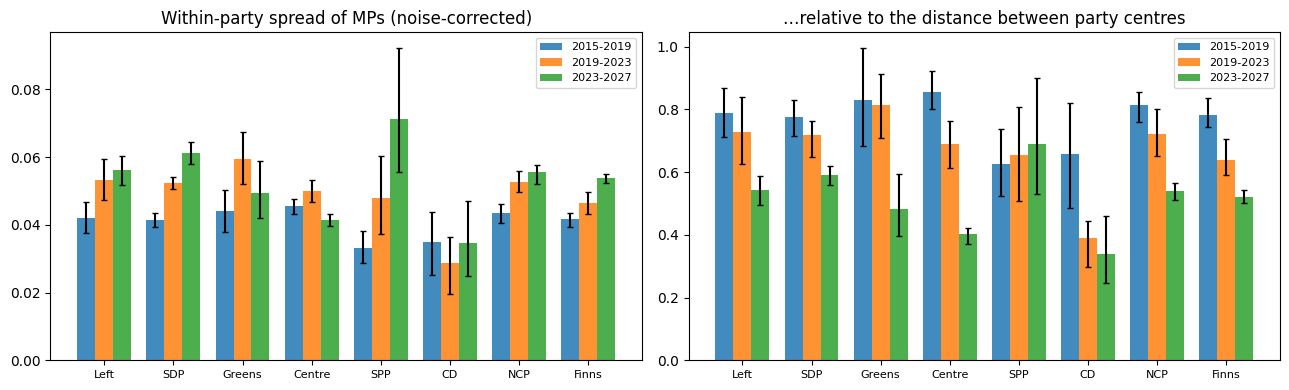

,diversity_naive,diversity,diversity_relative
term,,,
2015-2019,0.0433,0.0408,0.7657
2019-2023,0.0503,0.0488,0.6698
2023-2027,0.0545,0.0530,0.5136


In [8]:
oikea_hajonta = monimuotoisuus[monimuotoisuus["series"] == "real"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
leveys = 0.26
kuvat = [("diversity", "Within-party spread of MPs (noise-corrected)"),
         ("diversity_relative", "…relative to the distance between party centres")]
for j, (sarake, otsikko) in enumerate(kuvat):
    for k, kausi in enumerate(KAUDET):
        osa = oikea_hajonta[oikea_hajonta["term"] == kausi]
        luvut = osa.groupby("party")[sarake].apply(vali).unstack().reindex(PUOLUEET)
        alas = (luvut["mean"] - luvut["p10"]).clip(lower=0)
        ylos = (luvut["p90"] - luvut["mean"]).clip(lower=0)
        ax[j].bar(np.arange(len(PUOLUEET)) + (k - 1) * leveys, luvut["mean"], leveys,
                  yerr=[alas, ylos], capsize=2, label=kausi, alpha=0.85)
    ax[j].set_xticks(range(len(PUOLUEET)))
    ax[j].set_xticklabels(EN_LISTA, fontsize=8)
    ax[j].set_title(otsikko)
    ax[j].legend(fontsize=8)
plt.tight_layout()
plt.savefig(KUVAT + "res_diversity.png", bbox_inches="tight")
plt.show()

kaikki = oikea_hajonta.groupby("term")[["diversity_naive", "diversity", "diversity_relative"]].mean().round(4)
puolueittain = oikea_hajonta.groupby(["party", "term"])[["diversity", "diversity_relative", "own_prob", "n_mps_profiled"]].mean()
puolueittain = puolueittain.unstack("term").reindex(PUOLUEET).round(3)
taulukot.append("## Within-party diversity\n\n`diversity` = split-half (noise-corrected) spread of MP profiles around "
                "the party centre; `diversity_relative` = the same divided by the mean distance between party centres; "
                "`own_prob` = mean probability the model gives an MP's own party (chance = 0.125).\n\n"
                + kaikki.to_markdown() + "\n\n" + puolueittain.to_markdown())
kaikki

## 6. Leave-out-mittari ja vertailu

In [9]:
rivit = []
for kausi in KAUDET:
    luokittelija = parit[(parit["term"] == kausi) & (parit["series"] == "real")].groupby(["a", "b"])["d"].mean()
    gentzkow = leaveout[leaveout["term"] == kausi].set_index(["a", "b"])["pi"]
    yhdessa = pd.concat([luokittelija, gentzkow], axis=1, join="inner")
    rivit.append({"term": kausi, "spearman rho": yhdessa["d"].corr(yhdessa["pi"], method="spearman"), "pairs": len(yhdessa)})
vertailu = pd.DataFrame(rivit).round(3)

kausittain = leaveout.groupby("term")[["pi", "pi_random"]].mean()
kausittain["gov vs opp pi"] = leaveout_hallitus.set_index("term")["pi"]
kausittain["gov vs opp pi, random"] = leaveout_hallitus.set_index("term")["pi_random"]
kausittain = kausittain.round(4)

taulukot.append("## Agreement: classifier separability vs Gentzkow leave-out π (party pairs)\n\n" + vertailu.to_markdown(index=False))
taulukot.append("## Leave-out π by term (mean over the 28 party pairs; 0.5 = no difference)\n\n" + kausittain.to_markdown())
display(vertailu)
kausittain

,term,spearman rho,pairs
0,2015-2019,0.951,28
1,2019-2023,0.891,28
2,2023-2027,0.939,28


,pi,pi_random,gov vs opp pi,"gov vs opp pi, random"
term,,,,
2015-2019,0.5196,0.4948,0.5141,0.5006
2019-2023,0.5246,0.4962,0.5199,0.4990
2023-2027,0.5317,0.4942,0.5211,0.4989


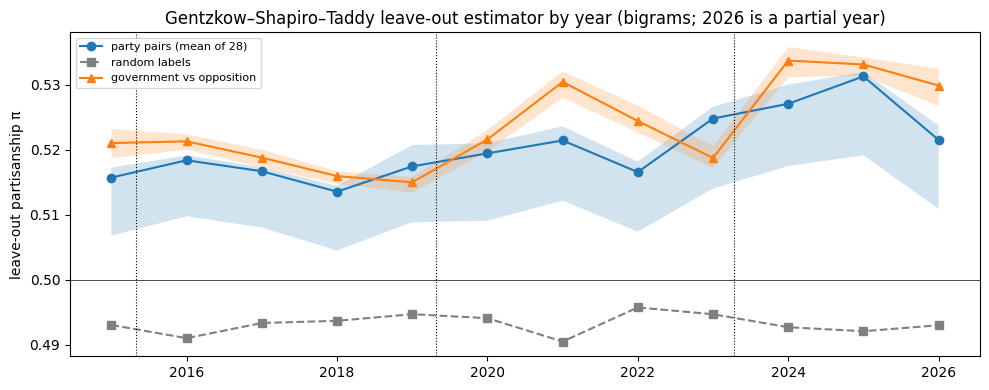

In [10]:
vuosittain = leaveout_vuosi.groupby("year")[["pi", "pi_random", "sub_lo", "sub_hi"]].mean()
hallitus_vuosi = leaveout_hallitus_vuosi.set_index("year")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(vuosittain.index, vuosittain["pi"], "o-", label="party pairs (mean of 28)")
ax.fill_between(vuosittain.index, vuosittain["sub_lo"], vuosittain["sub_hi"], alpha=0.2)
ax.plot(vuosittain.index, vuosittain["pi_random"], "s--", color="grey", label="random labels")
ax.plot(hallitus_vuosi.index, hallitus_vuosi["pi"], "^-", label="government vs opposition")
ax.fill_between(hallitus_vuosi.index, hallitus_vuosi["sub_lo"], hallitus_vuosi["sub_hi"], alpha=0.2)
for nimi, alku in config.TERMS:
    ax.axvline(alku.year + alku.dayofyear / 365, color="black", linestyle=":", linewidth=0.8)
ax.axhline(0.5, color="black", linewidth=0.5)
ax.set_ylabel("leave-out partisanship π")
ax.set_title("Gentzkow–Shapiro–Taddy leave-out estimator by year (bigrams; 2026 is a partial year)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(KUVAT + "res_leaveout_by_year.png", bbox_inches="tight")
plt.show()

## 7. Vaalikonevertailu

Kauden 2023–27 puhekartta ja vaalikonekartta rinnakkain sekä puolueparien vertailu. Luvut tulevat muistiosta 09, jossa on myös menetelmä ja tulkinta. Vaalikonekartta kierretään puhekartan asentoon (Procrustes), mikä ei muuta etäisyyksiä.

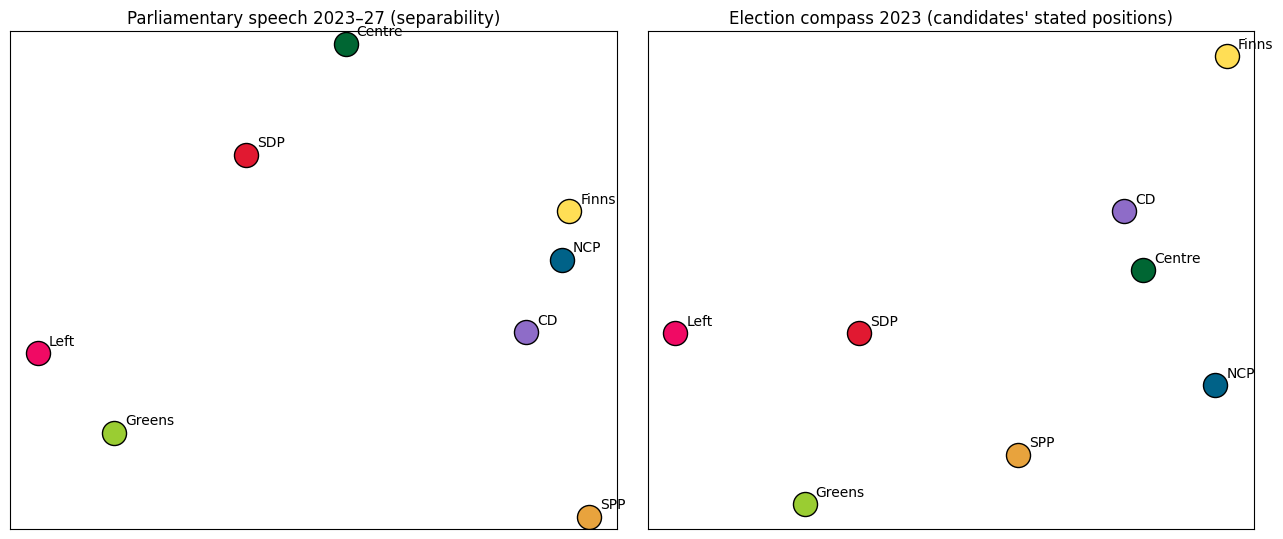

In [11]:
# vaalikone 2023 (kaikki ehdokkaat) vs. puheet 2023-27; muut vuodet ovat taulukossa alla
etaisyydet = pd.read_csv(TULOKSET + "vaalikone_distances.csv")
vaalikone = parimatriisi(etaisyydet[(etaisyydet["vuosi"] == 2023) & (etaisyydet["otos"] == "kaikki")], "etäisyys")
parivertailu = pd.read_csv(TULOKSET + "vaalikone_pair_comparison.csv")
parivertailu = parivertailu[parivertailu["vuosi"] == 2023]
mantel_tulos = pd.read_csv(TULOKSET + "vaalikone_vs_speech.csv")


def kierra_kohti(liikkuva, kohde):
    """Kierto ja peilaus (ei skaalausta), joka vie pistejoukon lähimmäs kohdetta."""
    a = liikkuva - liikkuva.mean(axis=0)
    b = kohde - kohde.mean(axis=0)
    u, s, vt = np.linalg.svd(a.T @ b)
    return a @ (u @ vt)


puhekartta = klassinen_mds(erottuvuusmatriisi("2023-2027").values)
puhekartta = puhekartta - puhekartta.mean(axis=0)
vaalikonekartta = kierra_kohti(klassinen_mds(vaalikone.values), puhekartta)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
kartat = [(puhekartta, "Parliamentary speech 2023–27 (separability)"),
          (vaalikonekartta, "Election compass 2023 (candidates' stated positions)")]
for k, (sijainnit, otsikko) in enumerate(kartat):
    for i, puolue in enumerate(PUOLUEET):
        ax[k].scatter(sijainnit[i, 0], sijainnit[i, 1], s=300, color=VARIT[puolue], edgecolor="black")
        ax[k].annotate(EN[puolue], sijainnit[i], xytext=(8, 6), textcoords="offset points")
    ax[k].set_title(otsikko)
    ax[k].set_xticks([])
    ax[k].set_yticks([])
    ax[k].grid(False)
    ax[k].set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.savefig(KUVAT + "res_compass_maps.png", bbox_inches="tight")
plt.show()

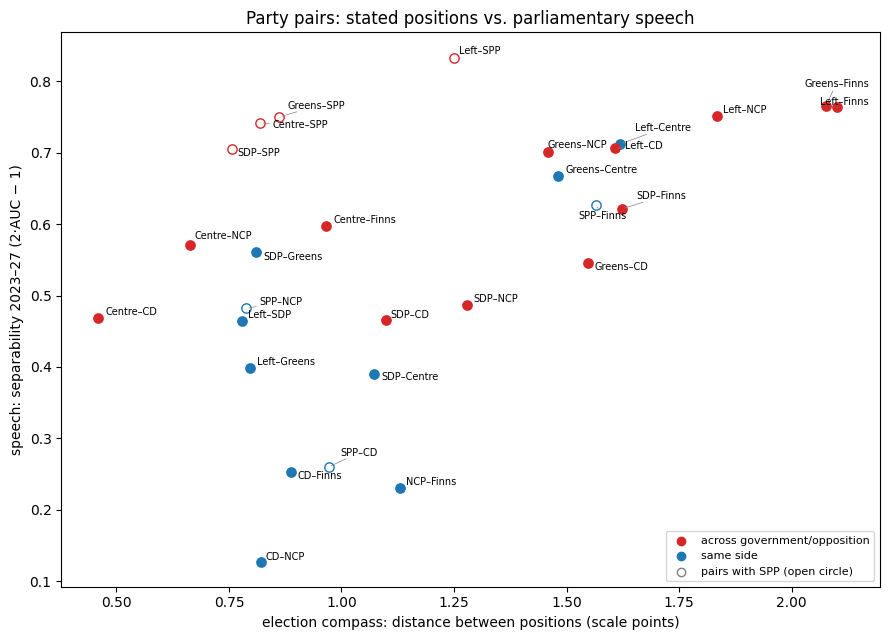

rank in compass  rank in speech  \
bloc            vuosi                                    
Left–SDP–Greens 2015               5.0             5.3   
                2019               5.0            11.7   
                2023               5.7             8.7   
NCP–Finns–CD    2015              16.3             7.3   
                2019              14.3             7.0   
                2023              12.0             2.0   

                       rank difference (speech − compass)  
bloc            vuosi                                      
Left–SDP–Greens 2015                                  0.3  
                2019                                  6.7  
                2023                                  3.0  
NCP–Finns–CD    2015                                 -9.0  
                2019                                 -7.3  
                2023                                -10.0

In [12]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(9, 6.5))
tekstit = []
for pari, x, y in zip(parivertailu["pari"], parivertailu["vaalikone"], parivertailu["puheet"]):
    a, b = pari.split("–")
    vari = "tab:blue" if samalla_puolella("2023-2027", a, b) else "tab:red"
    if "RKP" in (a, b):
        ax.scatter(x, y, facecolors="white", edgecolors=vari, s=45)
    else:
        ax.scatter(x, y, color=vari, s=45)
    tekstit.append(ax.text(x, y, EN[a] + "–" + EN[b], fontsize=7))
# siirretään nimet niin, etteivät ne mene päällekkäin (viiva osoittaa pisteeseen)
adjust_text(tekstit, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
ax.scatter([], [], color="tab:red", label="across government/opposition")
ax.scatter([], [], color="tab:blue", label="same side")
ax.scatter([], [], facecolors="white", edgecolors="grey", label="pairs with SPP (open circle)")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlabel("election compass: distance between positions (scale points)")
ax.set_ylabel("speech: separability 2023–27 (2·AUC − 1)")
ax.set_title("Party pairs: stated positions vs. parliamentary speech")
plt.tight_layout()
plt.savefig(KUVAT + "res_compass_vs_speech_pairs.png", bbox_inches="tight")
plt.show()

taulu = mantel_tulos.rename(columns={"vuosi": "compass year", "otos": "candidates", "puhemittari": "speech measure",
                                     "puolueet": "parties", "rho": "Spearman rho", "p": "Mantel p (exact)"})
taulu["candidates"] = taulu["candidates"].replace({"kaikki": "all", "valitut": "elected"})
taulu["speech measure"] = taulu["speech measure"].replace({"luokittelija": "separability (classifier)"})
taulu["parties"] = taulu["parties"].replace({"8 puoluetta": "8 parties", "ilman RKP": "without SPP"})
taulukot.append("## Election compass vs. speech in the following term (28 party pairs; 21 without SPP)\n\n"
                "2015 → 2015–19, 2019 → 2019–23, 2023 → 2023–27. Exact Mantel permutation test over all party orderings.\n\n"
                + taulu.to_markdown(index=False))

BLOKIT = {"NCP–Finns–CD": {"KOK", "PS", "KD"}, "Left–SDP–Greens": {"VAS", "SDP", "VIHR"}}


def blokki(pari):
    for nimi, puolueet in BLOKIT.items():
        if set(pari.split("–")) <= puolueet:
            return nimi
    return "other"


bloc = pd.read_csv(TULOKSET + "vaalikone_pair_comparison.csv")
bloc["bloc"] = bloc["pari"].apply(blokki)
bloc_taulu = bloc[bloc["bloc"] != "other"].groupby(["bloc", "vuosi"])[["sija vaalikone", "sija puheet", "sijaero"]].mean().round(1)
bloc_taulu.columns = ["rank in compass", "rank in speech", "rank difference (speech − compass)"]
taulukot.append("## Within-bloc party pairs: rank of closeness (1 = closest of 28 pairs)\n\n" + bloc_taulu.to_markdown())
bloc_taulu

## 8. Kuva: tunnusomaiset sanat (*distinctive words*)

Painot tulevat muistiosta 10 (`results/sanat_puolueittain.csv`), jossa ovat myös menetelmä ja tulkinta. Kuvassa on kunkin puolueen 10 painavinta fraasia niistä, joiden käytöstä korkeintaan puolet tulee yhdeltä edustajalta. Vaalea palkki = fraasi on 15 painavimman joukossa alle puolessa kymmenestä mallista.

Fraasit ovat suomen vartaloita, joten kuvateksti selittää ne englanniksi. Sama lista taulukkona menee `summary_tables.md`:hen.

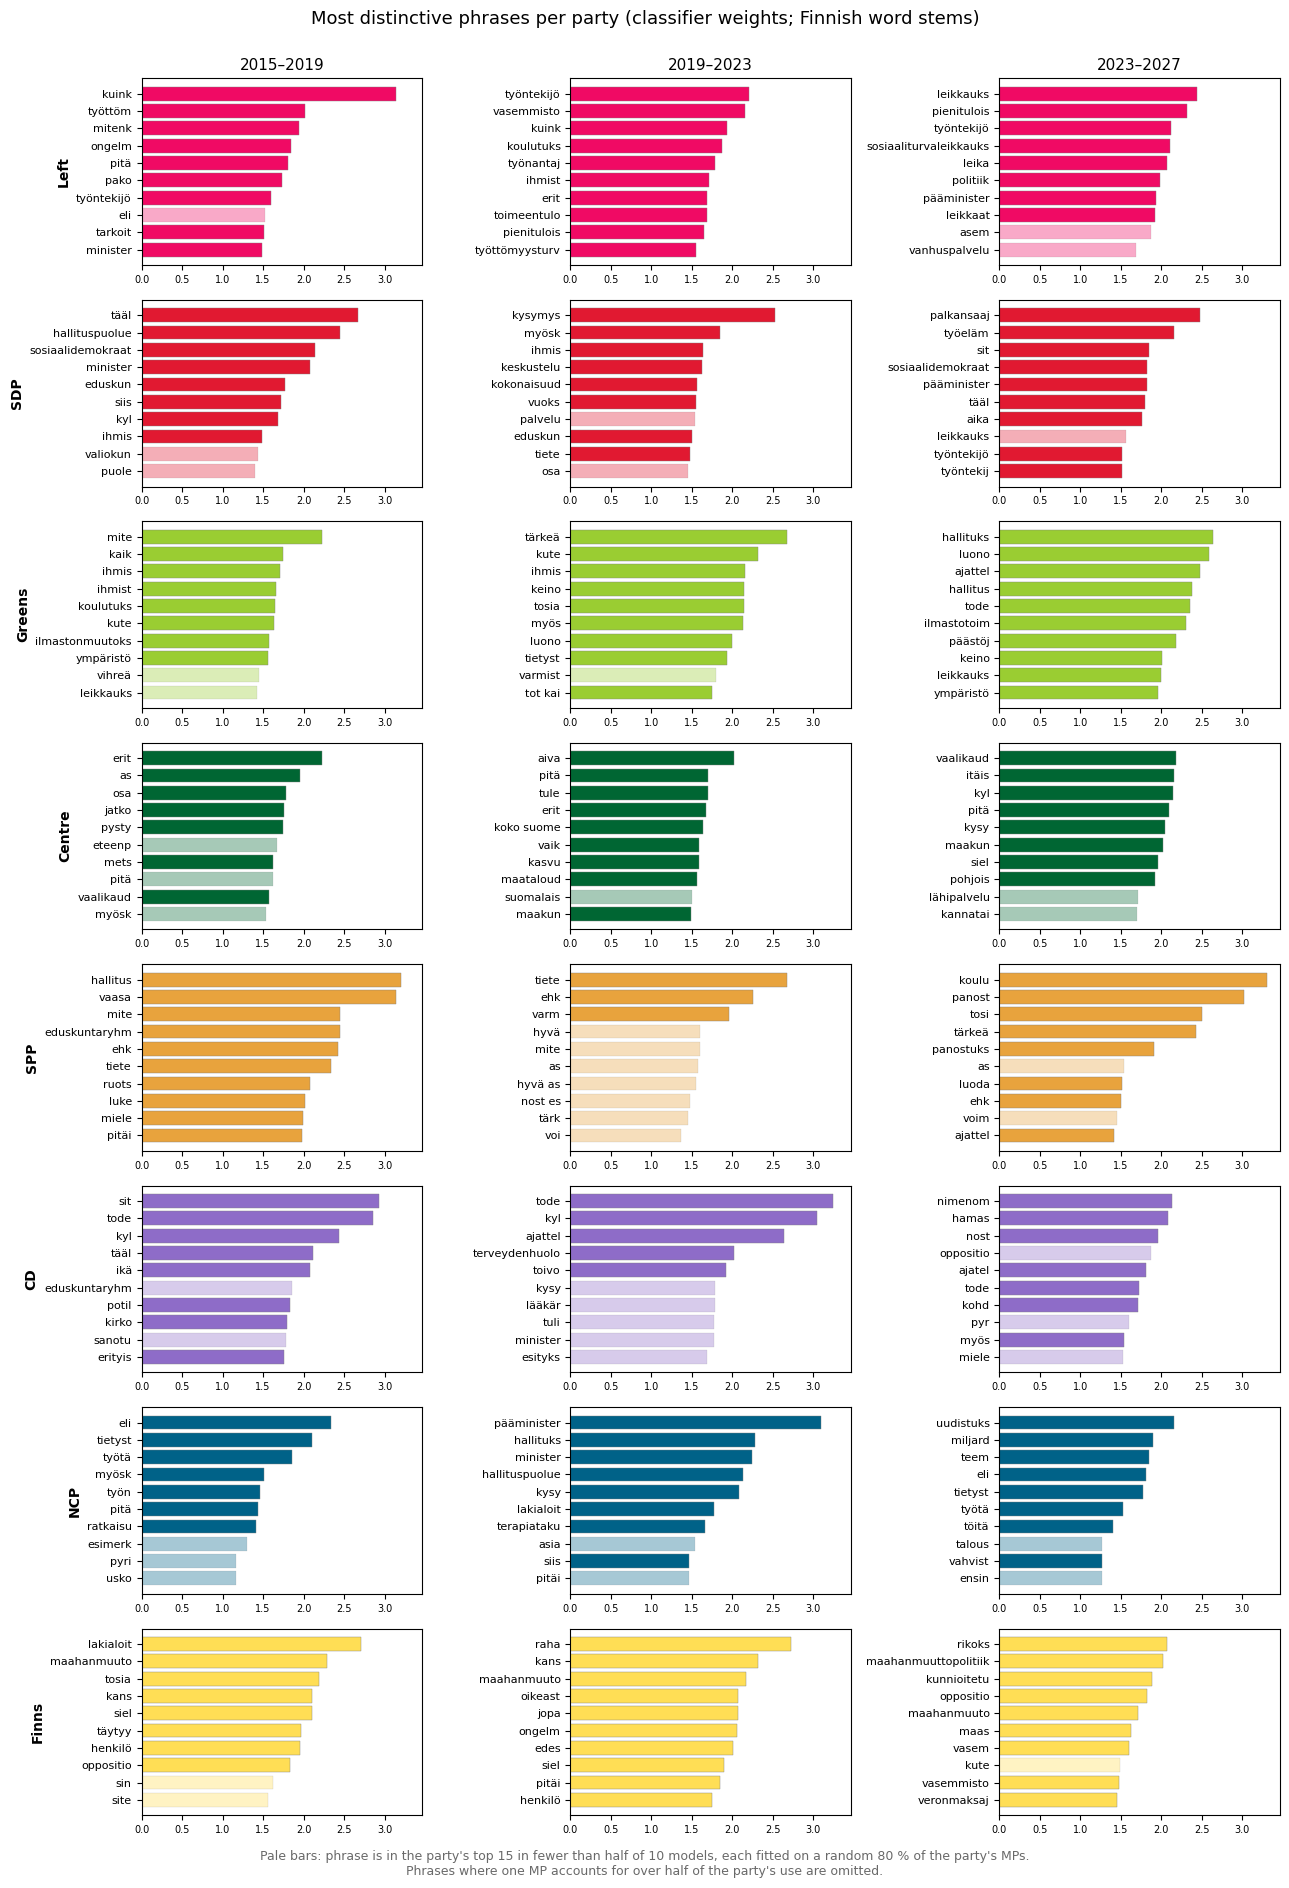

term,2015-2019,2019-2023,2023-2027
Left,"kuink, työttöm, mitenk, ongelm, pitä, pako, ty...","työntekijö, vasemmisto, kuink, koulutuks, työn...","leikkauks, pienitulois, työntekijö, sosiaalitu..."
SDP,"tääl, hallituspuolue, sosiaalidemokraat, minis...","kysymys, myösk, ihmis, keskustelu, kokonaisuud...","palkansaaj, työeläm, sit, sosiaalidemokraat, p..."
Greens,"mite, kaik, ihmis, ihmist, koulutuks, kute, il...","tärkeä, kute, ihmis, keino, tosia, myös, luono...","hallituks, luono, ajattel, hallitus, tode, ilm..."
Centre,"erit, as, osa, jatko, pysty, eteenp, mets, pitä","aiva, pitä, tule, erit, koko suome, vaik, kasv...","vaalikaud, itäis, kyl, pitä, kysy, maakun, sie..."
SPP,"hallitus, vaasa, mite, eduskuntaryhm, ehk, tie...","tiete, ehk, varm, hyvä, mite, as, hyvä as, nos...","koulu, panost, tosi, tärkeä, panostuks, as, lu..."
CD,"sit, tode, kyl, tääl, ikä, eduskuntaryhm, poti...","tode, kyl, ajattel, terveydenhuolo, toivo, kys...","nimenom, hamas, nost, oppositio, ajatel, tode,..."
NCP,"eli, tietyst, työtä, myösk, työn, pitä, ratkai...","pääminister, hallituks, minister, hallituspuol...","uudistuks, miljard, teem, eli, tietyst, työtä,..."
Finns,"lakialoit, maahanmuuto, tosia, kans, siel, täy...","raha, kans, maahanmuuto, oikeast, jopa, ongelm...","rikoks, maahanmuuttopolitiik, kunnioitetu, opp..."


In [13]:
sanat = pd.read_csv(TULOKSET + "sanat_puolueittain.csv")
yhteiset = sanat[sanat["top_speaker_share"] <= 0.5]   # ei yhden edustajan maneereja

fig, ax = plt.subplots(len(PUOLUEET), len(KAUDET), figsize=(13, 2.3 * len(PUOLUEET)))
suurin = yhteiset["weight"].max()
for i, puolue in enumerate(PUOLUEET):
    for j, kausi in enumerate(KAUDET):
        osa = yhteiset[(yhteiset["party"] == puolue) & (yhteiset["term"] == kausi)].head(10)
        y = np.arange(len(osa))[::-1]
        for yy, paino, pysyvyys in zip(y, osa["weight"], osa["stability"]):
            ax[i, j].barh(yy, paino, color=VARIT[puolue], alpha=1.0 if pysyvyys >= 0.5 else 0.35,
                          edgecolor="grey", linewidth=0.3)
        ax[i, j].set_yticks(y)
        ax[i, j].set_yticklabels(osa["phrase"], fontsize=8)
        ax[i, j].set_xlim(0, suurin * 1.05)
        ax[i, j].tick_params(axis="x", labelsize=7)
        if i == 0:
            ax[i, j].set_title(kausi.replace("-", "–"), fontsize=11)
        if j == 0:
            ax[i, j].set_ylabel(EN[puolue], fontsize=10, fontweight="bold")
fig.suptitle("Most distinctive phrases per party (classifier weights; Finnish word stems)", y=1.0, fontsize=13)
fig.tight_layout()
fig.text(0.5, 0, "Pale bars: phrase is in the party's top 15 in fewer than half of 10 models, each fitted on a random 80 % of the party's MPs.\n"
         "Phrases where one MP accounts for over half of the party's use are omitted.",
         ha="center", va="top", fontsize=9, color="dimgray")
fig.savefig(KUVAT + "res_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

lista = (yhteiset.groupby(["party", "term"]).head(8)
         .groupby(["party", "term"])["phrase"].agg(", ".join).unstack().loc[PUOLUEET])
lista.index = [EN[p] for p in lista.index]
taulukot.append("## Most distinctive phrases (Finnish stems; top 8 per party, excluding phrases where one MP "
                "accounts for over half of the party's use)\n\n" + lista.to_markdown())
lista

## 9. Kuva: erottuvuus teemoittain (*separability within topics*)

Luvut tulevat muistiosta 11, jossa ovat myös menetelmä ja tulkinta. Erottuvuus lasketaan vain saman teeman puheista (Gronowin ja Malkamäen hakusanat), kuuden suurimman puolueen 15 parista. Toinen paneeli on malli ilman tyylisanoja.

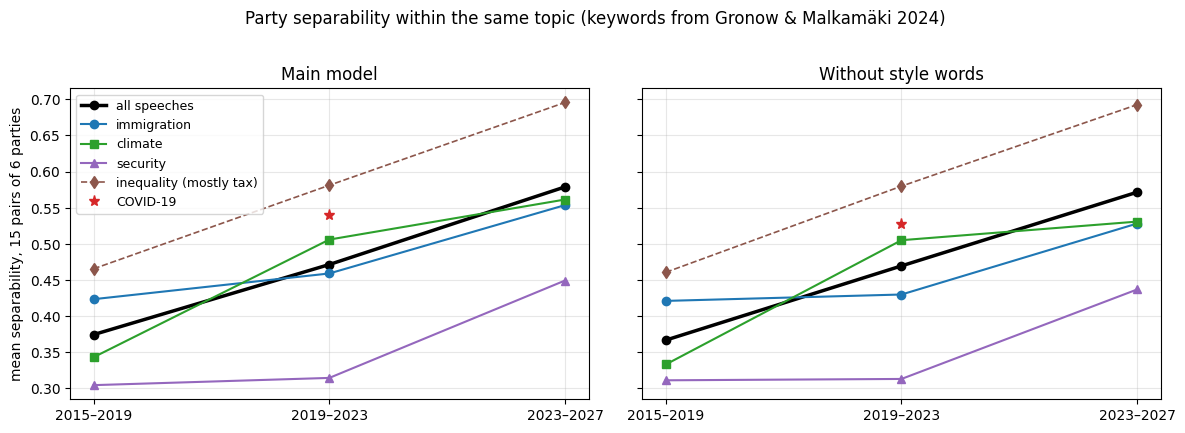

term                                         2015-2019  2019-2023  2023-2027
Main model          all speeches                  0.37       0.47       0.58
                    immigration                   0.42       0.46       0.55
                    climate                       0.34       0.51       0.56
                    security                      0.30       0.31       0.45
                    inequality (mostly tax)       0.47       0.58       0.70
                    COVID-19                       NaN       0.54        NaN
Without style words all speeches                  0.37       0.47       0.57
                    immigration                   0.42       0.43       0.53
                    climate                       0.33       0.50       0.53
                    security                      0.31       0.31       0.44
                    inequality (mostly tax)       0.46       0.58       0.69
                    COVID-19                       NaN       0.53        NaN

In [14]:
teemaparit = pd.read_csv(TULOKSET + "teemat_pairwise.csv")
TEEMAT_EN = {"kaikki": "all speeches", "maahanmuutto": "immigration", "ilmasto": "climate",
             "turvallisuus": "security", "eriarvoisuus": "inequality (mostly tax)", "korona": "COVID-19"}
MALLIT_EN = {"party": "Main model", "party_nostyle": "Without style words"}
teemakeskiarvot = teemaparit.groupby(["malli", "teema", "term", "a", "b"])["d"].mean().reset_index()

rivit = []
kuvan_arvot = {}
for malli in MALLIT_EN:
    for teema in TEEMAT_EN:
        osa = teemakeskiarvot[(teemakeskiarvot["malli"] == malli) & (teemakeskiarvot["teema"] == teema)]
        tarvitaan = 1 if teema == "korona" else 3
        kausia = osa.groupby(["a", "b"])["term"].nunique()
        yhteiset = kausia[kausia >= tarvitaan].index
        osa = osa.set_index(["a", "b"]).loc[yhteiset].reset_index()
        rivi = osa.groupby("term")["d"].mean().reindex(KAUDET)
        kuvan_arvot[(MALLIT_EN[malli], TEEMAT_EN[teema])] = rivi.to_numpy()
        rivi["model"] = MALLIT_EN[malli]
        rivi["topic"] = TEEMAT_EN[teema]
        rivit.append(rivi)
teematulos = pd.DataFrame(rivit).set_index(["model", "topic"]).reindex(columns=KAUDET)
teematulos = teematulos.reindex(pd.MultiIndex.from_product([MALLIT_EN.values(), TEEMAT_EN.values()]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
x = np.arange(len(KAUDET))
tyylit = {"all speeches": ("k", "o-", 2.5), "immigration": ("#1f77b4", "o-", 1.5), "climate": ("#2ca02c", "s-", 1.5),
          "security": ("#9467bd", "^-", 1.5), "inequality (mostly tax)": ("#8c564b", "d--", 1.2),
          "COVID-19": ("#d62728", "*", 1.5)}
for j, malli in enumerate(MALLIT_EN.values()):
    for teema, (vari, merkki, paksuus) in tyylit.items():
        arvot = kuvan_arvot[(malli, teema)]
        ax[j].plot(x, arvot, merkki, color=vari, linewidth=paksuus, markersize=8 if teema == "COVID-19" else 6,
                   label=teema)
    ax[j].set_xticks(x)
    ax[j].set_xticklabels([k.replace("-", "–") for k in KAUDET])
    ax[j].set_title(malli)
    ax[j].grid(alpha=0.3)
ax[0].set_ylabel("mean separability, 15 pairs of 6 parties")
ax[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Party separability within the same topic (keywords from Gronow & Malkamäki 2024)", y=1.02)
fig.tight_layout()
fig.savefig(KUVAT + "res_polarisation_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()

taulukot.append("## Separability within topics (6 largest parties, 15 pairs; notebook 11)\n\n"
                + teematulos.round(2).to_markdown())
teematulos.round(2)

## 10. Sekaannusmatriisit ja tallennus

In [15]:
with open(TULOKSET + "party_confusion.json") as f:
    sekaannukset = json.load(f)
for kausi in KAUDET:
    matriisi = pd.DataFrame(sekaannukset[kausi]).reindex(index=PUOLUEET, columns=PUOLUEET).round(2)
    taulukot.append(f"## Confusion matrix {kausi} (rows = true party, share of its speeches)\n\n" + matriisi.to_markdown())

selite = "Party codes: " + ", ".join(k + " = " + config.PARTY_NAMES_EN[k] for k in config.PARTY_ORDER)
with open(TULOKSET + "summary_tables.md", "w", encoding="utf-8") as f:
    f.write(selite + "\n\n" + "\n\n".join(taulukot) + "\n")
print("Kirjoitettu results/summary_tables.md")

Kirjoitettu results/summary_tables.md
